# Fuel price prediction by postcode in Greater Sydney

## (1) Preprocessing...

In [1]:
%run PREPROCESS.py

--------------------------------------------------------------------------------
Beginning Merging Individual Datasets, Complete Dataset...
--------------------------------------------------------------------------------
Step 1: Loading all datasets...
Step 2: Standardizing dates...
Step 3: Merging all data layers...
Step 4: Filling weekend gaps for market data...
--------------------------------------------------------------------------------
SUCCESS: datasets/COMPLETE_DATASET.csv is ready.
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 82120 entries, 172 to 82024
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ServiceStationName  82120 non-null  object        
 1   Address             82120 non-null  object        
 2   Suburb              82120 non-null  object        
 3   Postcode            82120 non-n

## (2) Training...

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid') # clean plot style

# Check that datasets/MODEL_READY_DATASET.csv exists
if not os.path.isfile("datasets/MODEL_READY_DATASET.csv"):
    print("Error: datasets/MODEL_READY_DATASET.csv does not exist yet")
    print("Please run the 'Preprocessing' code block of this notebook")
    print("Alternatively, run the PREPROCESS.py script directly")
    raise SystemExit

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load the data
df = pd.read_csv('datasets/MODEL_READY_DATASET.csv')

# # 2. Separate Features (X) and Target (y)
# X = df.drop(columns=['target_next_day_price'])
# y = df['target_next_day_price']

# # 3. Split into Training (80%) and Testing (20%) sets
# # We use random_state=42 so your results are reproducible
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

# 3. Separate features and target
target_col = 'target_next_day_price'
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

# 4. Instantiate and Train the Baseline Linear Regression (Using SCALED data)
lr = LinearRegression()
lr.fit(X_train, y_train)

# 5. Generate Predictions on the future test vault
lr_preds = lr.predict(X_test)

# 4. Initialize and Train the Random Forest
# n_estimators=100 is a good start (100 trees)
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
print("Training the forest... this might take a minute...")
model.fit(X_train, y_train)

# 5. Evaluate the model
predictions = model.predict(X_test)
rf_mae = mean_absolute_error(y_test, predictions)
rf_r2 = r2_score(y_test, predictions)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print("--- Updated Baseline Random Forest (Unscaled Chronological Split) ---")
print(f"Baseline RF MAE: {rf_mae:.4f} cents")
print(f"Baseline RF R2:  {rf_r2:.4f}\n")

print("--- Updated Baseline Linear Regression (Scaled Chronological Split) ---")
print(f"Baseline Linear Regression MAE: {lr_mae:.4f} cents")
print(f"Baseline Linear Regression R2:  {lr_r2:.4f}\n")

Training the forest... this might take a minute...
--- Updated Baseline Random Forest (Unscaled Chronological Split) ---
Baseline RF MAE: 8.6638 cents
Baseline RF R2:  0.3432

--- Updated Baseline Linear Regression (Scaled Chronological Split) ---
Baseline Linear Regression MAE: 5.2431 cents
Baseline Linear Regression R2:  0.5618



In [3]:
# 1. Extract feature importances
importances = model.feature_importances_
feature_names = X_test.columns

# 2. Create a clean DataFrame for viewing
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance Ranking ---")
print(feature_importance_df)


--- Feature Importance Ranking ---
                Feature  Importance
1                 price    0.712991
8    postcode_daily_avg    0.120432
0              postcode    0.035605
9   postcode_rolling_7d    0.033621
3              temp_min    0.012725
6            tgp_sydney    0.010926
2              temp_max    0.010219
11      oil_price_lag_7    0.009680
12     tgp_sydney_lag_1    0.008197
13     tgp_sydney_lag_7    0.007098
5             oil_price    0.006734
15        aud_usd_lag_7    0.006026
14        aud_usd_lag_1    0.005714
10      oil_price_lag_1    0.005708
7               aud_usd    0.005673
4              rainfall    0.004736
16          day_of_week    0.003916


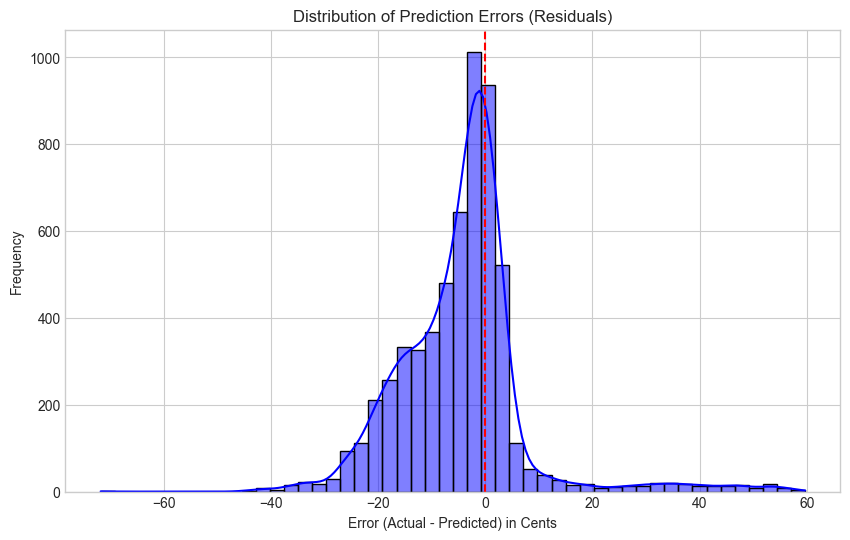

In [4]:
residuals = y_test - predictions
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=50, color='blue')
plt.title('Distribution of Prediction Errors (Residuals)')
plt.xlabel('Error (Actual - Predicted) in Cents')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--')
plt.show()

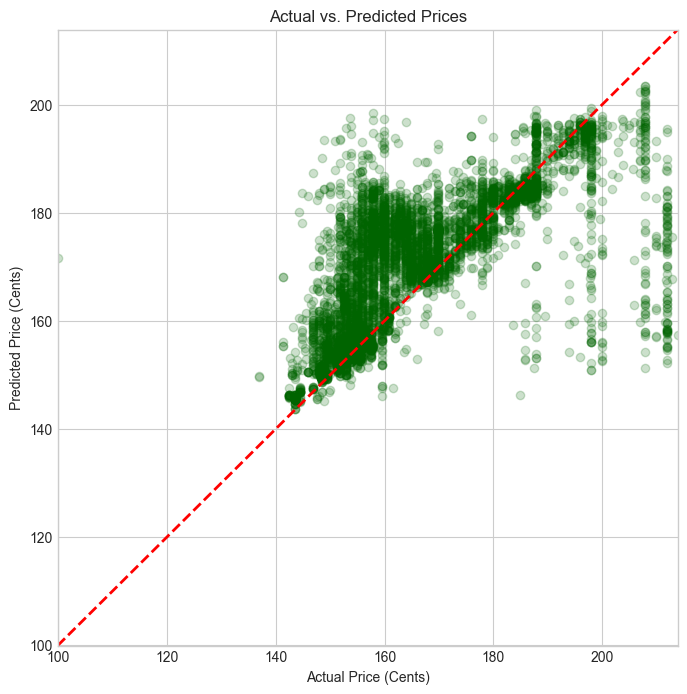

In [5]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, predictions, alpha=0.2, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Prices')
# Tighten the limits to see the "core" of the data
plt.xlim(y_test.min(), y_test.max())
plt.ylim(y_test.min(), y_test.max())
plt.xlabel('Actual Price (Cents)')
plt.ylabel('Predicted Price (Cents)')
plt.show()

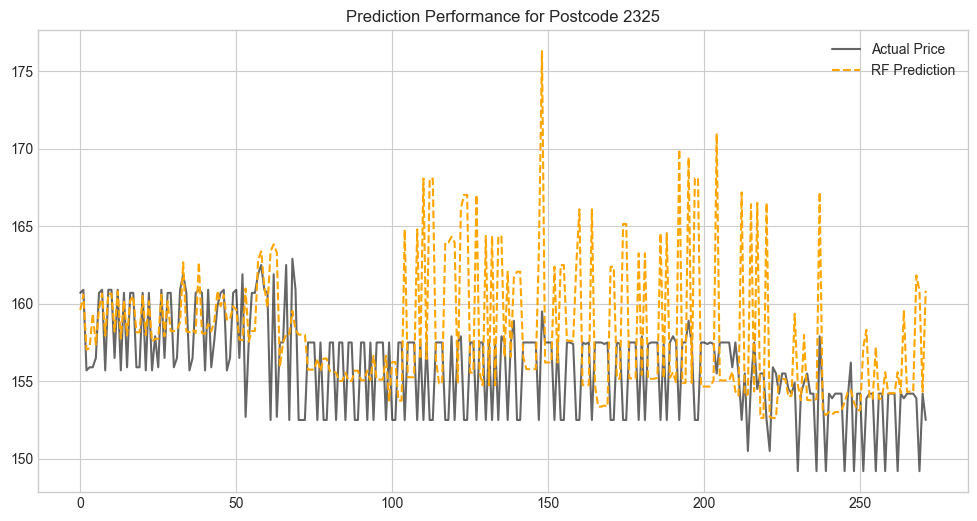

In [6]:
# Create a small dataframe for the test results
test_results = X_test.copy()
test_results['actual'] = y_test
test_results['predicted'] = predictions

# Pick one postcode to visualize (e.g., the most common one)
sample_postcode = test_results['postcode'].mode()[0]
sample_data = test_results[test_results['postcode'] == sample_postcode].sort_index()

plt.figure(figsize=(12, 6))
plt.plot(sample_data['actual'].values, label='Actual Price', color='black', alpha=0.6)
plt.plot(sample_data['predicted'].values, label='RF Prediction', color='orange', linestyle='--')
plt.title(f'Prediction Performance for Postcode {sample_postcode}')
plt.legend()
plt.show()

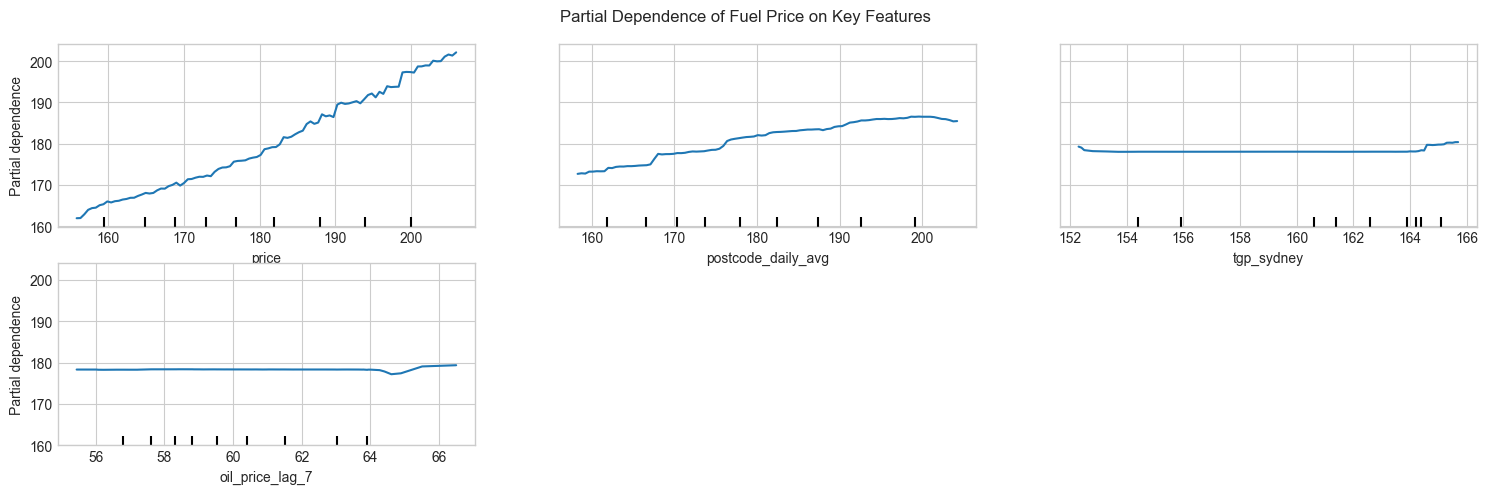

In [7]:
from sklearn.inspection import PartialDependenceDisplay

# Choose the top 3-4 features from your importance list
features_to_plot = ['price', 'postcode_daily_avg', 'tgp_sydney', 'oil_price_lag_7']

fig, ax = plt.subplots(figsize=(15, 5))
PartialDependenceDisplay.from_estimator(model, X_train, features_to_plot, ax=ax)
plt.suptitle('Partial Dependence of Fuel Price on Key Features')
plt.tight_layout()
plt.show()

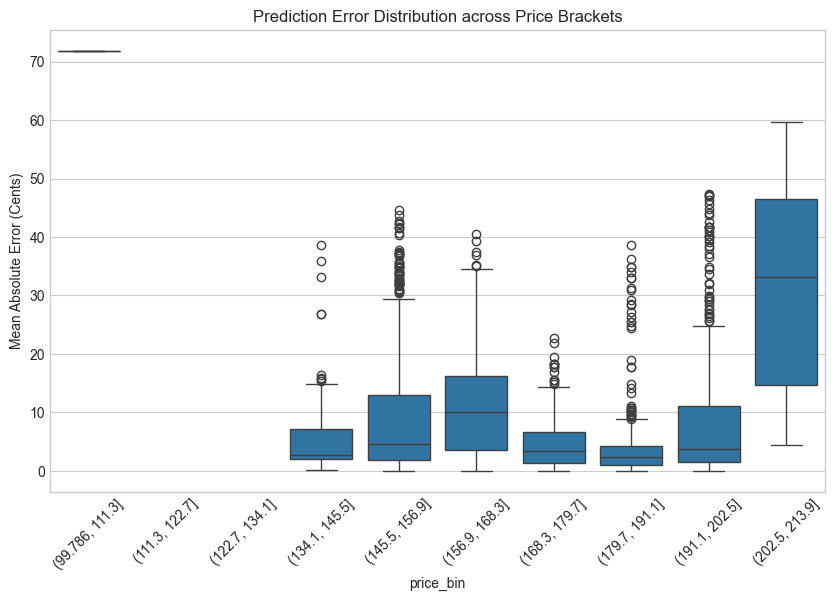

In [8]:
test_results = pd.DataFrame({'actual': y_test, 'predicted': predictions})
test_results['error'] = (test_results['actual'] - test_results['predicted']).abs()

# Bin the prices into $0.10 increments
test_results['price_bin'] = pd.cut(test_results['actual'], bins=10)

plt.figure(figsize=(10, 6))
sns.boxplot(x='price_bin', y='error', data=test_results)
plt.xticks(rotation=45)
plt.title('Prediction Error Distribution across Price Brackets')
plt.ylabel('Mean Absolute Error (Cents)')
plt.show()

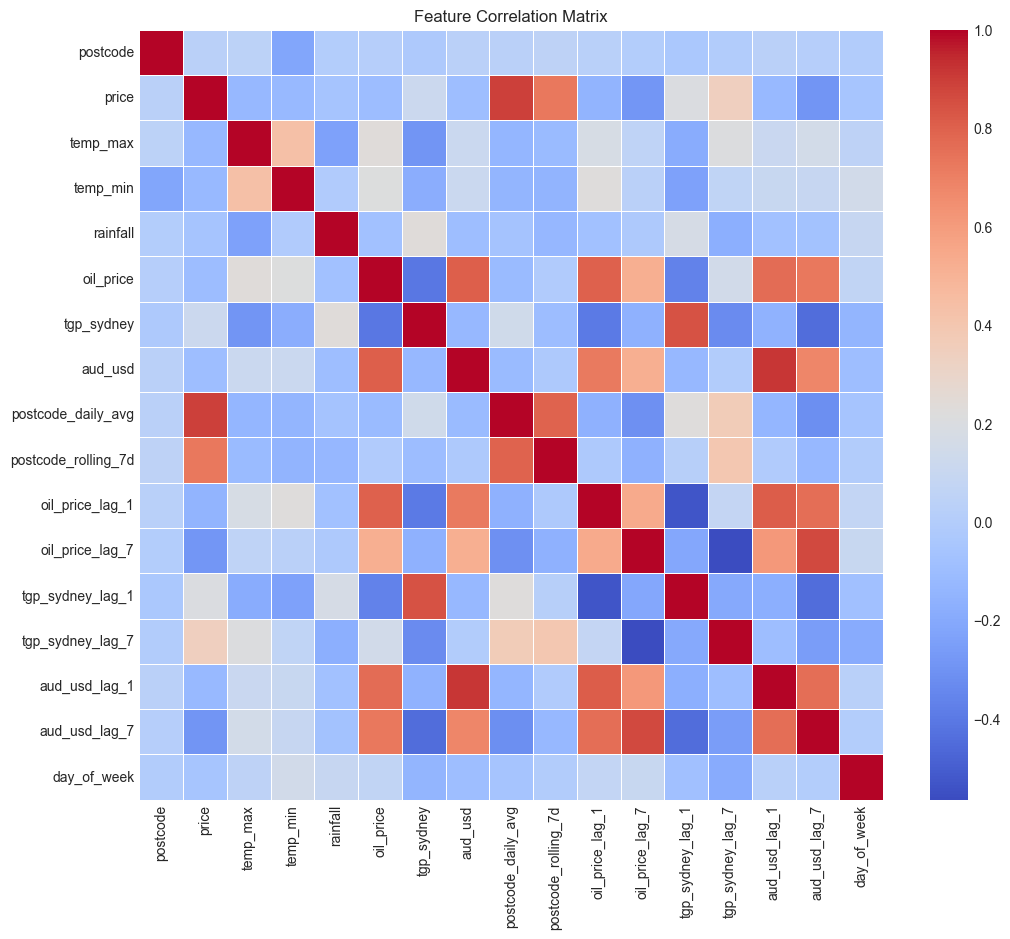

In [9]:
plt.figure(figsize=(12, 10))
correlation_matrix = X_test.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

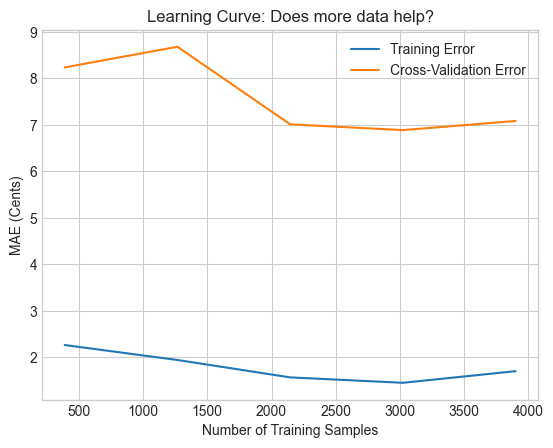

In [10]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    RandomForestRegressor(n_estimators=20, n_jobs=-1), X_test, y_test, cv=3, 
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='neg_mean_absolute_error'
)

plt.plot(train_sizes, -train_scores.mean(axis=1), label='Training Error')
plt.plot(train_sizes, -test_scores.mean(axis=1), label='Cross-Validation Error')
plt.title('Learning Curve: Does more data help?')
plt.xlabel('Number of Training Samples')
plt.ylabel('MAE (Cents)')
plt.legend()
plt.show()